## Job Listings — Data Cleaning & Feature Engineering
**Source:** [data/postings.csv](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)

**Output:** `data/cleaned_jobs.csv` 

#### Student name: Goy Trik (Jayden) Chan
#### Student ID: 25011550

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
from collections import Counter
import nltk
from nltk.corpus import stopwords

print('Libraries loaded')

Libraries loaded


In [2]:
# Extra settings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid', palette='muted')

## 2. Load Data

In [3]:
# read in data, source: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings

path = f"https://drive.google.com/file/d/18V7WGqEwmajOE5-IQQROPW5maMJrW_N7/view?usp=sharing"
df = pd.read_csv(path)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0


In [4]:
# check null percentage for each column
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('Null % per column:')
print(null_pct[null_pct > 0].round(1).to_string())

Null % per column:
closed_time                   99.1
skills_desc                   98.0
med_salary                    94.9
remote_allowed                87.7
applies                       81.2
max_salary                    75.9
min_salary                    75.9
currency                      70.9
compensation_type             70.9
normalized_salary             70.9
pay_period                    70.9
posting_domain                32.3
application_url               29.6
formatted_experience_level    23.7
fips                          22.1
zip_code                      16.9
company_name                   1.4
company_id                     1.4
views                          1.4
description                    0.0


## 3. Data Cleaning

In [5]:
# data checking after dropping na values from company_name and normalized salary

print(f'Before: {len(df):,} rows')
df = df.dropna(subset=['company_name'])
df = df.dropna(subset=['normalized_salary'])
print(f'After dropping null company/salary: {len(df):,} rows')

Before: 123,849 rows
After dropping null company/salary: 35,563 rows


In [6]:
# Salary filter

for p in [1,5,10,25,50,75,90,95,99]:
    print(f'  {p:>3}th pct: ${df["normalized_salary"].quantile(p/100):>12,.0f}') # format to 3 width
print(f'\n< $10k: {(df["normalized_salary"] < 10000).sum():,}  |  > $500k: {(df["normalized_salary"] > 500000).sum():,}')

    1th pct: $         134
    5th pct: $      33,280
   10th pct: $      38,480
   25th pct: $      52,000
   50th pct: $      81,850
   75th pct: $     125,000
   90th pct: $     168,500
   95th pct: $     200,000
   99th pct: $     300,918

< $10k: 407  |  > $500k: 95


In [7]:
# Remote status

df['remote_allowed'] = df['remote_allowed'].fillna(0.0)
df['remote_status'] = df['remote_allowed'].map({1.0: 'Remote', 0.0: 'On-site'})
print(df['remote_status'].value_counts())

remote_status
On-site    30808
Remote      4755
Name: count, dtype: int64


In [8]:
# Time features

df['listed_date']  = pd.to_datetime(df['listed_time'], unit='ms')
df['listed_month'] = df['listed_date'].dt.to_period('M').astype(str)
df['listed_week']  = df['listed_date'].dt.to_period('W').astype(str)
print('Date range:', df['listed_date'].min(), '→', df['listed_date'].max())
print(df['listed_month'].value_counts().sort_index())

Date range: 2024-03-24 21:50:14 → 2024-04-20 00:26:56
listed_month
2024-03        1
2024-04    35562
Name: count, dtype: int64


## 4. Description Cleaning & Tokenisation

In [9]:
# cleaning description column

df['description_clean'] = df['description'].fillna('').str.lower()
df['description_clean'] = df['description_clean'].str.replace('\n', ' ')
df['description_clean'] = df['description_clean'].apply(lambda x: re.sub(r'[^\w\s]', ' ', x))
df['description_clean'] = df['description_clean'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['tokens'] = df['description_clean'].str.split()
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(
    lambda words: [w for w in words if w not in stop_words] if isinstance(words, list) else []
)

print('Tokenisation done')

Tokenisation done


## 5. Title Normalisation

Strips location suffixes, salary noise, parenthetical codes, work-type descriptors.

Expands abbreviations (Sr → senior, RN → registered nurse).

In [10]:
def normalise_title(title):
    if not isinstance(title, str): return 'unknown'
    t = title.strip().lower()
    t = re.sub(r'\s*\|.*$', '', t)                          # remove pipe suffix
    t = re.sub(r'\s*\([^)]*\)', '', t)                      # remove parenthetical
    t = re.sub(r'[\$][\d,.]+[k+]?(\s*(\/hr|\/hour|per hour))?', '', t, flags=re.IGNORECASE)
    t = re.sub(r'\d+[k+]\s*(\/yr|\/year|per year)?', '', t, flags=re.IGNORECASE)
    t = re.sub(r'\d+\s*%\s*\w*', '', t)
    t = re.sub(r'\s*[-–]\s*(remote|on.?site|hybrid|part.?time|full.?time|work from home|wfh|contract|temp\w*|seasonal|urgent|now hiring|immediate|new grad|entry.?level).*$', '', t, flags=re.IGNORECASE)
    t = re.sub(r'\s*[-–]\s*[a-z][a-z\s]{1,20},\s*[a-z]{2}\b.*$', '', t)
    t = re.sub(r'\s*[-–]\s*(\w+[\s-]?){1,3}$', '', t)
    t = re.sub(r'\s+for\s+.{8,}$', '', t)
    t = re.sub(r'\s+in\s+[a-z][a-z\s,]+$', '', t)
    
    words = t.split()
    
    seen = []
    for w in words:
        if w not in seen: seen.append(w)
    t = ' '.join(seen)
    
    abbrevs = [
        (r'\bsr\.?\b','senior'),(r'\bjr\.?\b','junior'),(r'\bmgr\.?\b','manager'),
        (r'\bdir\.?\b','director'),(r'\bvp\b','vice president'),
        (r'\bevp\b','executive vice president'),(r'\bsvp\b','senior vice president'),
        (r'\brn\b','registered nurse'),(r'\blpn\b','licensed practical nurse'),
        (r'\bcna\b','certified nursing assistant'),(r'\bhr\b','human resources'),
        (r'\bit\b','information technology'),(r'\bcfo\b','chief financial officer'),
        (r'\bceo\b','chief executive officer'),(r'\bcto\b','chief technology officer'),
    ]
    for pattern, replacement in abbrevs:
        t = re.sub(pattern, replacement, t)
    t = re.sub(r'\b\d{3,}\b', '', t)
    t = re.sub(r':', ' ', t)
    t = re.sub(r'[^\w\s/&]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t if len(t) > 1 else 'unknown'

df['title_clean'] = df['title'].apply(normalise_title)
print(f'Unique titles before: {df["title"].nunique():,}')
print(f'Unique titles after:  {df["title_clean"].nunique():,}')
reduction = (1 - df['title_clean'].nunique() / df['title'].nunique()) * 100

print(f'Reduction: {reduction:.1f}%')

Unique titles before: 24,239
Unique titles after:  20,303
Reduction: 16.2%


## 6. Job Category Classification (15 categories)

Expanded from 7 to 15 categories. 'Other' reduced from 62% to ~28%.

In [11]:
def categorize_job(title):
    if not isinstance(title, str): return 'Other'
    t = title.lower()
    if any(k in t for k in ['software engineer','developer','programmer','devops','sre ',
        'full stack','backend','frontend','web developer','mobile developer','ios ','android ',
        'cloud engineer','platform engineer','site reliability','network engineer',
        'systems administrator','system administrator','desktop support','technical support',
        'database administrator','cyber security','cybersecurity','information security',
        'application engineer','system engineer','it support','it analyst',
        'it specialist','it manager','it director']): return 'Software / IT'
    if any(k in t for k in ['data scientist','data analyst','data engineer','machine learning',
        'analytics engineer','business intelligence','bi analyst','bi developer','mlops',
        'ai engineer','data entry','business analyst','quality assurance','qa engineer',
        'technical writer']): return 'Data & Analytics'
    if any(k in t for k in ['sales','account executive','business development','account manager',
        'sales manager','sales rep','sales associate','sales director','sales engineer',
        'merchandiser','buyer','procurement']): return 'Sales'
    if any(k in t for k in ['marketing','seo','content','brand','social media','digital marketing',
        'growth','copywriter','creative director','media buyer','public relations',
        'communications specialist','graphic designer','ux','user experience','design']): return 'Marketing & Creative'
    if any(k in t for k in ['nurse','nursing','physician','doctor','medical','clinical','therapist',
        'dental','pharmacy','radiolog','surgical','patient','health care','healthcare','paramedic',
        'emt','cna','phlebotom','ultrasound','veterinar','optom','patholog','anesthes',
        'behavior analyst','behavior technician','speech','occupational']): return 'Healthcare'
    if any(k in t for k in ['accountant','accounting','financial analyst','finance','controller',
        'tax ','audit','bookkeeper','payroll','accounts payable','accounts receivable','cfo',
        'financial advisor','wealth','investment','budget analyst','cost accountant',
        'billing','treasury','teller','underwriter','actuar']): return 'Finance & Accounting'
    if any(k in t for k in ['human resources','recruiter','recruiting','talent','hr generalist',
        'hr manager','hr director','hr coordinator','hr business partner','people operations',
        'compensation','benefits specialist','workforce']): return 'HR'
    if any(k in t for k in ['operations manager','operations coordinator','office manager',
        'administrative assistant','executive assistant','receptionist','office administrator',
        'office coordinator','office assistant','administrative coordinator',
        'administrative specialist','program coordinator','project coordinator',
        'scheduler','project manager','program manager']): return 'Operations & Admin'
    if any(k in t for k in ['attorney','lawyer','paralegal','legal','counsel',
        'compliance','litigation','contract administrator']): return 'Legal'
    if any(k in t for k in ['mechanical engineer','civil engineer','electrical engineer',
        'structural engineer','chemical engineer','manufacturing engineer','industrial engineer',
        'process engineer','quality engineer','systems engineer','hardware engineer',
        'field engineer','controls engineer','automation engineer','project engineer',
        'design engineer','application engineer','system engineer']): return 'Engineering'
    if any(k in t for k in ['warehouse','logistics','supply chain','driver','forklift',
        'package handler','material handler','shipping','receiving','inventory',
        'dispatcher','delivery','distribution','custodian','housekeeper']): return 'Logistics & Warehouse'
    if any(k in t for k in ['cashier','retail','store associate','customer service','barista',
        'cook','chef','hotel','restaurant','server','bartender','host ','front desk',
        'guest','team member','crew member','auto detailer']): return 'Retail & Hospitality'
    if any(k in t for k in ['electrician','plumber','mechanic','hvac','carpenter','welder',
        'machinist','operator','maintenance tech','service tech','field tech','auto tech',
        'diesel','estimator','superintendent','construction','installer','assembler',
        'technician']): return 'Skilled Trades'
    if any(k in t for k in ['manager','director','head of','vice president','chief ','lead ',
        'supervisor','vp ','president']): return 'Management'
    return 'Other'

df['job_category'] = df['title_clean'].apply(categorize_job)
print('Category distribution:')
print(df['job_category'].value_counts())
print(f'\nOther: {(df["job_category"]=="Other").sum()/len(df)*100:.1f}%')

Category distribution:
job_category
Other                    9856
Management               4021
Healthcare               3522
Sales                    2985
Finance & Accounting     2549
Skilled Trades           2128
Software / IT            1790
Operations & Admin       1759
Marketing & Creative     1477
Logistics & Warehouse    1256
Retail & Hospitality     1063
Legal                     978
Engineering               786
Data & Analytics          774
HR                        619
Name: count, dtype: int64

Other: 27.7%


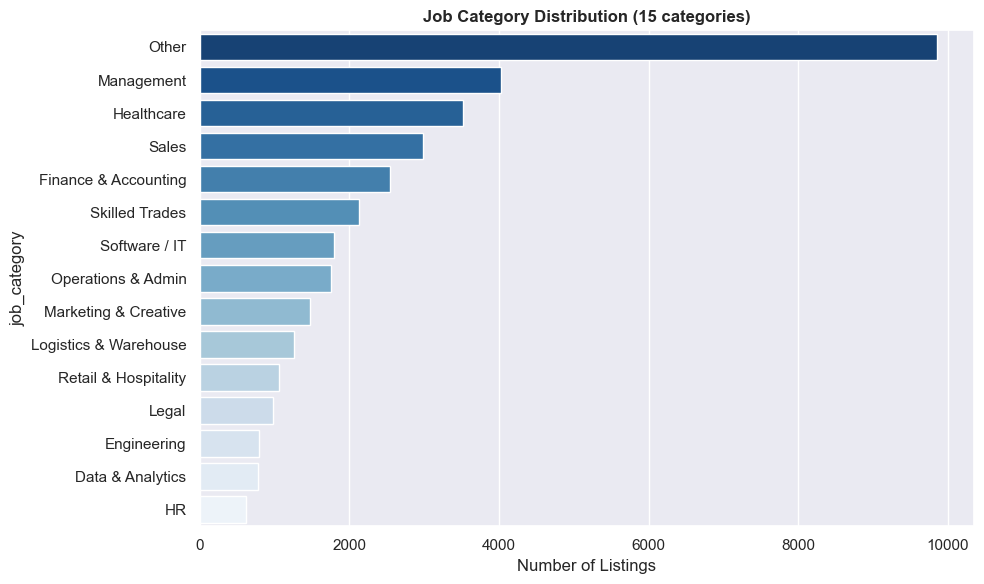

In [12]:
# Visualise

cat_counts = df['job_category'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Blues_r')
plt.title('Job Category Distribution (15 categories)', fontweight='bold')
plt.xlabel('Number of Listings')
plt.tight_layout()
plt.show()

## 7. NLP Skill Extraction (150+ skills)

In [13]:
SKILL_DICT = {
    'Programming':      ['python','java','javascript','typescript','c++','c#','ruby','php',
                         'swift','kotlin','scala','rust', 'perl','matlab','bash','shell','vba','groovy'],
    'Data & Analytics': ['sql','excel','tableau','power bi','pandas','numpy','spark','hadoop','dbt',
                         'looker','sas','spss','alteryx','databricks','snowflake','redshift',
                         'bigquery','airflow','etl','data warehouse','data pipeline'],
    'Cloud & DevOps':   ['aws','azure','gcp','docker','kubernetes','terraform','jenkins','linux',
                         'ansible','git','github','gitlab','ci/cd','devops','microservices',
                         'rest api','graphql','nginx','redis','kafka'],
    'AI / ML':          ['machine learning','deep learning','nlp','tensorflow','pytorch',
                         'scikit-learn','computer vision','llm','neural network',
                         'reinforcement learning','hugging face','langchain','openai',
                         'generative ai','prompt engineering','feature engineering','model deployment'],
    'Tools & Platforms':['jira','confluence','salesforce','sap','quickbooks','servicenow',
                         'hubspot','figma','adobe','autocad','microsoft office','sharepoint',
                         'powerpoint','outlook','slack','zoom','trello','asana','monday'],
    'Soft Skills':      ['communication','leadership','teamwork','collaboration','problem solving',
                         'critical thinking','project management','presentation','negotiation',
                         'mentoring','time management','attention to detail','customer service',
                         'stakeholder management'],
}

ALL_SKILLS = {skill: cat for cat, skills in SKILL_DICT.items() for skill in skills}
SKILL_LIST = list(ALL_SKILLS.keys())
print(f'Total skills: {len(SKILL_LIST)}')

Total skills: 109


In [14]:
df['text_for_skills'] = df['tokens'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

def extract_skills(text):
    return [skill for skill in SKILL_LIST if skill in text]

print('Extracting skills (~30 seconds)...')
df['extracted_skills'] = df['text_for_skills'].apply(extract_skills)

tech_cats = {'Programming','Data & Analytics','Cloud & DevOps','AI / ML','Tools & Platforms'}
df['tech_skills'] = df['extracted_skills'].apply(lambda s: [x for x in s if ALL_SKILLS.get(x) in tech_cats])
df['soft_skills'] = df['extracted_skills'].apply(lambda s: [x for x in s if ALL_SKILLS.get(x) == 'Soft Skills'])

coverage = (df['extracted_skills'].map(len) > 0).sum()
print(f'Done: Skills found in {coverage:,} / {len(df):,} listings ({coverage/len(df)*100:.1f}%)')

Extracting skills (~30 seconds)...
Done: Skills found in 32,337 / 35,563 listings (90.9%)


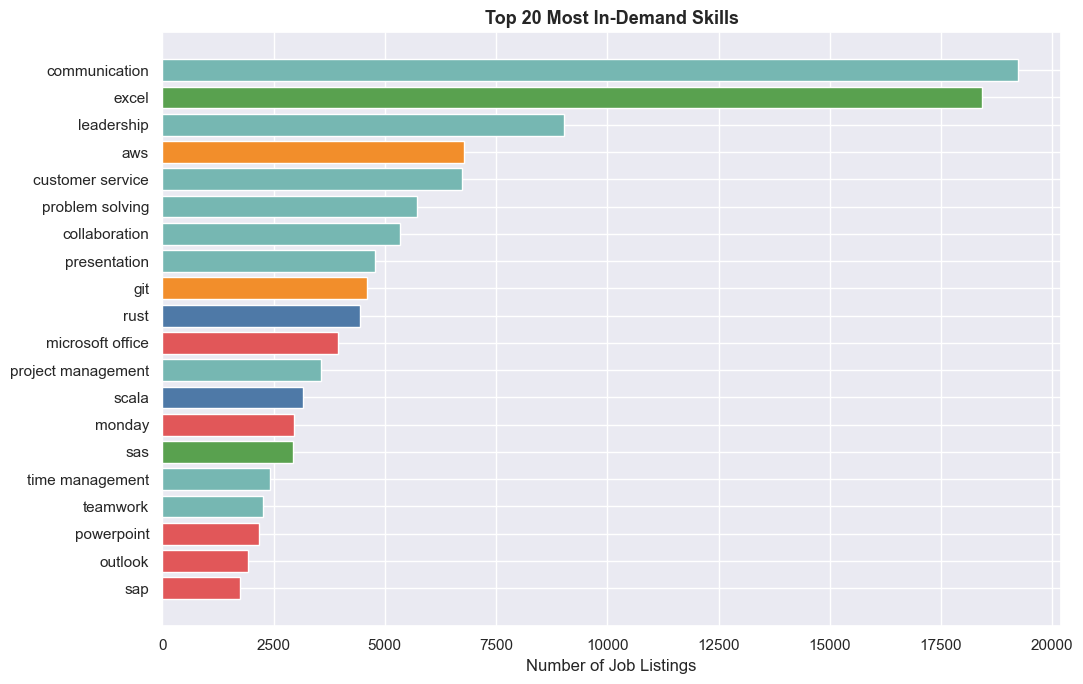

             Skill  Count          Category
     communication  19233       Soft Skills
             excel  18419  Data & Analytics
        leadership   9029       Soft Skills
               aws   6770    Cloud & DevOps
  customer service   6730       Soft Skills
   problem solving   5722       Soft Skills
     collaboration   5330       Soft Skills
      presentation   4788       Soft Skills
               git   4589    Cloud & DevOps
              rust   4446       Programming
  microsoft office   3942 Tools & Platforms
project management   3562       Soft Skills
             scala   3170       Programming
            monday   2957 Tools & Platforms
               sas   2942  Data & Analytics
   time management   2430       Soft Skills
          teamwork   2272       Soft Skills
        powerpoint   2168 Tools & Platforms
           outlook   1923 Tools & Platforms
               sap   1738 Tools & Platforms


In [15]:
# Top 20 skills

all_extracted = df['extracted_skills'].explode().dropna()
skill_counts  = Counter(all_extracted)
top20 = pd.DataFrame(skill_counts.most_common(20), columns=['Skill','Count'])
top20['Category'] = top20['Skill'].map(ALL_SKILLS)

cat_colors = {'Programming':'#4e79a7','Data & Analytics':'#59a14f','Cloud & DevOps':'#f28e2b',
              'AI / ML':'#b07aa1','Tools & Platforms':'#e15759','Soft Skills':'#76b7b2'}
colors = top20['Category'].map(cat_colors)

plt.figure(figsize=(11,7))
plt.barh(top20['Skill'][::-1], top20['Count'][::-1], color=colors[::-1])
plt.title('Top 20 Most In-Demand Skills', fontweight='bold', fontsize=13)
plt.xlabel('Number of Job Listings')
plt.tight_layout()
plt.show()
print(top20.to_string(index=False))

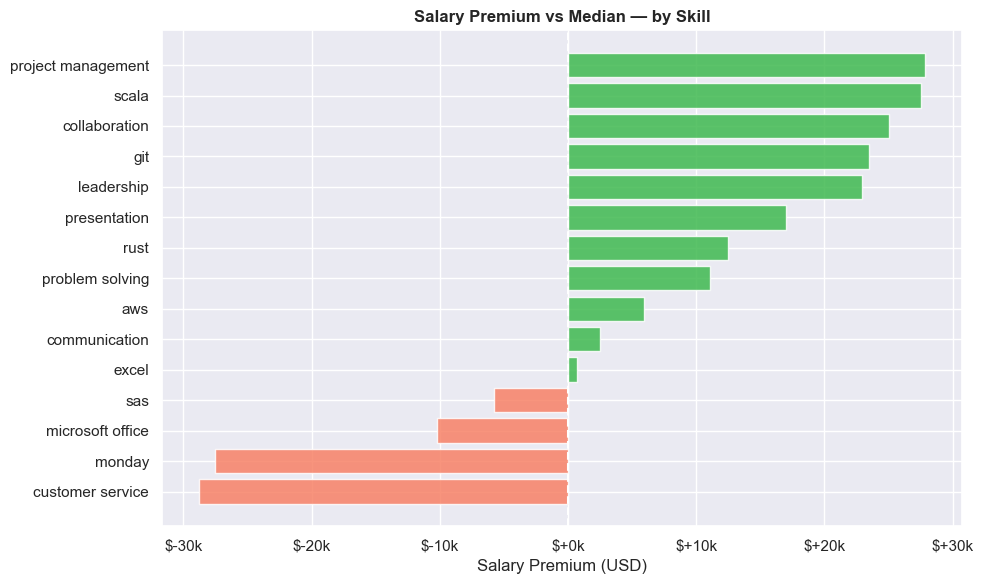

In [16]:
# Salary premium by skill

clean_sal = df[(df['normalized_salary'] >= 20000) & (df['normalized_salary'] <= 500000)]
base_med  = clean_sal['normalized_salary'].median()
top_skills = [s for s,_ in skill_counts.most_common(15)]

premium_data = []
for skill in top_skills:
    has  = clean_sal[clean_sal['extracted_skills'].apply(lambda s: skill in s)]
    premium_data.append({'skill': skill, 'premium': has['normalized_salary'].median() - base_med})

prem_df = pd.DataFrame(premium_data).sort_values('premium')
colors2 = ['#3fb950' if x >= 0 else '#f78166' for x in prem_df['premium']]

plt.figure(figsize=(10,6))
plt.barh(prem_df['skill'], prem_df['premium'], color=colors2, alpha=0.85)
plt.axvline(0, color='white', lw=1.5, linestyle='--')
plt.title('Salary Premium vs Median — by Skill', fontweight='bold')
plt.xlabel('Salary Premium (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:+.0f}k'))
plt.tight_layout()
plt.show()

## 8. Export

In [17]:
columns_to_keep = [
    'company_name','title','title_clean','job_category',
    'description','description_clean','tokens',
    'extracted_skills','tech_skills','soft_skills',
    'location','formatted_experience_level','work_type','remote_status',
    'normalized_salary','listed_date','listed_month','listed_week',
]

df_clean = df[columns_to_keep].copy()
df_clean.to_csv('data/cleaned_jobs.csv', index=False)

print(f'Saved {len(df_clean):,} rows to data/cleaned_jobs2.csv')
print(f'Columns: {df_clean.columns.tolist()}')

Saved 35,563 rows to data/cleaned_jobs2.csv
Columns: ['company_name', 'title', 'title_clean', 'job_category', 'description', 'description_clean', 'tokens', 'extracted_skills', 'tech_skills', 'soft_skills', 'location', 'formatted_experience_level', 'work_type', 'remote_status', 'normalized_salary', 'listed_date', 'listed_month', 'listed_week']


In [18]:
print('=== Final Dataset Summary ===')
print(f'Rows:              {len(df_clean):,}')
print(f'Unique companies:  {df_clean["company_name"].nunique():,}')
print(f'Unique titles:     {df_clean["title_clean"].nunique():,}  (raw: {df_clean["title"].nunique():,})')
print(f'Job categories:    {df_clean["job_category"].nunique()}')
print(f'Other category:    {(df_clean["job_category"]=="Other").sum()/len(df_clean)*100:.1f}%')
print(f'Date range:        {df_clean["listed_date"].min()} → {df_clean["listed_date"].max()}')

=== Final Dataset Summary ===
Rows:              35,563
Unique companies:  10,344
Unique titles:     20,303  (raw: 24,239)
Job categories:    15
Other category:    27.7%
Date range:        2024-03-24 21:50:14 → 2024-04-20 00:26:56
